<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E6%BC%94%E7%BF%92_7_%E7%94%BB%E5%83%8F%E8%AA%8D%E8%AD%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
デジタル画像処理演習

#**画像認識**

2026/07/12 改訂

---

この演習では次の内容を学習します。
1. 画像のクラス分類
1. 一般物体認識
1. セマンティックセグメンテーション

次に書かれている「準備」から順番に進めていってください。  

<a name="junbi"></a>
# **準備**

最初に準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
from google.colab.patches import cv2_imshow
from ipywidgets import interact, IntSlider, FloatSlider

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imagefiles.zip" -O imagefiles.zip
!unzip -nq imagefiles.zip
!rm -f imagefiles.zip
!if [[ -f "asagao.png" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されれば成功です。
次のライブラリや関数が使えるようになっています。

|名称|説明|
|:---|:---|
|cv2|画像処理ライブラリ OpenCV|
|np|数値計算ライブラリ NumPy|
|plt|グラフ描画ライブラリ Matplotlib|
|cv2_imshow|Colab専用の画像表示関数|

画像ファイルも用意されています。Colab の画面の左端にある「ファイル」アイコン（📁の形）をクリックするとファイルブラウザが表示されて、ファイルの一覧を見ることができます。もう一度クリックすると非表示になります。  
自分のパソコンに保存してある画像ファイルを Colab で使いたい場合には、このファイルブラウザの中へ画像ファイルをドラッグ＆ドロップしてください。

<br>

# **1．画像のクラス分類**

画像のクラス分類は、事前に定められたクラス（人、犬、車など）のどれかに画像を仕分ける処理です。

ここでは、深層学習（Deep Learning）によるクラス分類を行います。

初めに、クラス分類を行うニューラルネットワークのモデル「MobileNet V2」のデータファイルをダウンロードします。これは学習がすでに完了しているデータで、1000種類の物体を識別することができます。

次のコードを実行してください。

In [ ]:
#@title ⌨ MobileNetV2の読み込み
#https://github.com/opencv/opencv_zoo
!wget -nc -O mobilenetv2.onnx https://github.com/opencv/opencv_zoo/raw/refs/heads/main/models/image_classification_mobilenet/image_classification_mobilenetv2_2022apr.onnx
!if [ -f "mobilenetv2.onnx" ]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi
# モデルの設定
model_cl = cv2.dnn.ClassificationModel('mobilenetv2.onnx')
model_cl.setInputParams(1/255, (224, 224), [0.485, 0.456, 0.406], True, False)

続けて、次のコードを実行してください （コードがとても長いので非表示にしています）。  
このコードでは、1000個のクラスの名前のリストを作成しています。

In [ ]:
#@title ⌨ クラスの名前を登録
#ImageNet
labels1k = ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 'sidewinder', 'trilobite', 'harvestman', 'scorpion', 'black and gold garden spider', 'barn spider', 'garden spider', 'black widow', 'tarantula', 'wolf spider', 'tick', 'centipede', 'black grouse', 'ptarmigan', 'ruffed grouse', 'prairie chicken', 'peacock', 'quail', 'partridge', 'African grey', 'macaw', 'sulphur-crested cockatoo', 'lorikeet', 'coucal', 'bee eater', 'hornbill', 'hummingbird', 'jacamar', 'toucan', 'drake', 'red-breasted merganser', 'goose', 'black swan', 'tusker', 'echidna', 'platypus', 'wallaby', 'koala', 'wombat', 'jellyfish', 'sea anemone', 'brain coral', 'flatworm', 'nematode', 'conch', 'snail', 'slug', 'sea slug', 'chiton', 'chambered nautilus', 'Dungeness crab', 'rock crab', 'fiddler crab', 'king crab', 'American lobster', 'spiny lobster', 'crayfish', 'hermit crab', 'isopod', 'white stork', 'black stork', 'spoonbill', 'flamingo', 'little blue heron', 'American egret', 'bittern', 'crane', 'limpkin', 'European gallinule', 'American coot', 'bustard', 'ruddy turnstone', 'red-backed sandpiper', 'redshank', 'dowitcher', 'oystercatcher', 'pelican', 'king penguin', 'albatross', 'grey whale', 'killer whale', 'dugong', 'sea lion', 'Chihuahua', 'Japanese spaniel', 'Maltese dog', 'Pekinese', 'Shih-Tzu', 'Blenheim spaniel', 'papillon', 'toy terrier', 'Rhodesian ridgeback', 'Afghan hound', 'basset', 'beagle', 'bloodhound', 'bluetick', 'black-and-tan coonhound', 'Walker hound', 'English foxhound', 'redbone', 'borzoi', 'Irish wolfhound', 'Italian greyhound', 'whippet', 'Ibizan hound', 'Norwegian elkhound', 'otterhound', 'Saluki', 'Scottish deerhound', 'Weimaraner', 'Staffordshire bullterrier', 'American Staffordshire terrier', 'Bedlington terrier', 'Border terrier', 'Kerry blue terrier', 'Irish terrier', 'Norfolk terrier', 'Norwich terrier', 'Yorkshire terrier', 'wire-haired fox terrier', 'Lakeland terrier', 'Sealyham terrier', 'Airedale', 'cairn', 'Australian terrier', 'Dandie Dinmont', 'Boston bull', 'miniature schnauzer', 'giant schnauzer', 'standard schnauzer', 'Scotch terrier', 'Tibetan terrier', 'silky terrier', 'soft-coated wheaten terrier', 'West Highland white terrier', 'Lhasa', 'flat-coated retriever', 'curly-coated retriever', 'golden retriever', 'Labrador retriever', 'Chesapeake Bay retriever', 'German short-haired pointer', 'vizsla', 'English setter', 'Irish setter', 'Gordon setter', 'Brittany spaniel', 'clumber', 'English springer', 'Welsh springer spaniel', 'cocker spaniel', 'Sussex spaniel', 'Irish water spaniel', 'kuvasz', 'schipperke', 'groenendael', 'malinois', 'briard', 'kelpie', 'komondor', 'Old English sheepdog', 'Shetland sheepdog', 'collie', 'Border collie', 'Bouvier des Flandres', 'Rottweiler', 'German shepherd', 'Doberman', 'miniature pinscher', 'Greater Swiss Mountain dog', 'Bernese mountain dog', 'Appenzeller', 'EntleBucher', 'boxer', 'bull mastiff', 'Tibetan mastiff', 'French bulldog', 'Great Dane', 'Saint Bernard', 'Eskimo dog', 'malamute', 'Siberian husky', 'dalmatian', 'affenpinscher', 'basenji', 'pug', 'Leonberg', 'Newfoundland', 'Great Pyrenees', 'Samoyed', 'Pomeranian', 'chow', 'keeshond', 'Brabancon griffon', 'Pembroke', 'Cardigan', 'toy poodle', 'miniature poodle', 'standard poodle', 'Mexican hairless', 'timber wolf', 'white wolf', 'red wolf', 'coyote', 'dingo', 'dhole', 'African hunting dog', 'hyena', 'red fox', 'kit fox', 'Arctic fox', 'grey fox', 'tabby', 'tiger cat', 'Persian cat', 'Siamese cat', 'Egyptian cat', 'cougar', 'lynx', 'leopard', 'snow leopard', 'jaguar', 'lion', 'tiger', 'cheetah', 'brown bear', 'American black bear', 'ice bear', 'sloth bear', 'mongoose', 'meerkat', 'tiger beetle', 'ladybug', 'ground beetle', 'long-horned beetle', 'leaf beetle', 'dung beetle', 'rhinoceros beetle', 'weevil', 'fly', 'bee', 'ant', 'grasshopper', 'cricket', 'walking stick', 'cockroach', 'mantis', 'cicada', 'leafhopper', 'lacewing', 'dragonfly', 'damselfly', 'admiral', 'ringlet', 'monarch', 'cabbage butterfly', 'sulphur butterfly', 'lycaenid', 'starfish', 'sea urchin', 'sea cucumber', 'wood rabbit', 'hare', 'Angora', 'hamster', 'porcupine', 'fox squirrel', 'marmot', 'beaver', 'guinea pig', 'sorrel', 'zebra', 'hog', 'wild boar', 'warthog', 'hippopotamus', 'ox', 'water buffalo', 'bison', 'ram', 'bighorn', 'ibex', 'hartebeest', 'impala', 'gazelle', 'Arabian camel', 'llama', 'weasel', 'mink', 'polecat', 'black-footed ferret', 'otter', 'skunk', 'badger', 'armadillo', 'three-toed sloth', 'orangutan', 'gorilla', 'chimpanzee', 'gibbon', 'siamang', 'guenon', 'patas', 'baboon', 'macaque', 'langur', 'colobus', 'proboscis monkey', 'marmoset', 'capuchin', 'howler monkey', 'titi', 'spider monkey', 'squirrel monkey', 'Madagascar cat', 'indri', 'Indian elephant', 'African elephant', 'lesser panda', 'giant panda', 'barracouta', 'eel', 'coho', 'rock beauty', 'anemone fish', 'sturgeon', 'gar', 'lionfish', 'puffer', 'abacus', 'abaya', 'academic gown', 'accordion', 'acoustic guitar', 'aircraft carrier', 'airliner', 'airship', 'altar', 'ambulance', 'amphibian', 'analog clock', 'apiary', 'apron', 'ashcan', 'assault rifle', 'backpack', 'bakery', 'balance beam', 'balloon', 'ballpoint', 'Band Aid', 'banjo', 'bannister', 'barbell', 'barber chair', 'barbershop', 'barn', 'barometer', 'barrel', 'barrow', 'baseball', 'basketball', 'bassinet', 'bassoon', 'bathing cap', 'bath towel', 'bathtub', 'beach wagon', 'beacon', 'beaker', 'bearskin', 'beer bottle', 'beer glass', 'bell cote', 'bib', 'bicycle-built-for-two', 'bikini', 'binder', 'binoculars', 'birdhouse', 'boathouse', 'bobsled', 'bolo tie', 'bonnet', 'bookcase', 'bookshop', 'bottlecap', 'bow', 'bow tie', 'brass', 'brassiere', 'breakwater', 'breastplate', 'broom', 'bucket', 'buckle', 'bulletproof vest', 'bullet train', 'butcher shop', 'cab', 'caldron', 'candle', 'cannon', 'canoe', 'can opener', 'cardigan', 'car mirror', 'carousel', 'carpenters kit', 'carton', 'car wheel', 'cash machine', 'cassette', 'cassette player', 'castle', 'catamaran', 'CD player', 'cello', 'cellular telephone', 'chain', 'chainlink fence', 'chain mail', 'chain saw', 'chest', 'chiffonier', 'chime', 'china cabinet', 'Christmas stocking', 'church', 'cinema', 'cleaver', 'cliff dwelling', 'cloak', 'clog', 'cocktail shaker', 'coffee mug', 'coffeepot', 'coil', 'combination lock', 'computer keyboard', 'confectionery', 'container ship', 'convertible', 'corkscrew', 'cornet', 'cowboy boot', 'cowboy hat', 'cradle', 'crane', 'crash helmet', 'crate', 'crib', 'Crock Pot', 'croquet ball', 'crutch', 'cuirass', 'dam', 'desk', 'desktop computer', 'dial telephone', 'diaper', 'digital clock', 'digital watch', 'dining table', 'dishrag', 'dishwasher', 'disk brake', 'dock', 'dogsled', 'dome', 'doormat', 'drilling platform', 'drum', 'drumstick', 'dumbbell', 'Dutch oven', 'electric fan', 'electric guitar', 'electric locomotive', 'entertainment center', 'envelope', 'espresso maker', 'face powder', 'feather boa', 'file', 'fireboat', 'fire engine', 'fire screen', 'flagpole', 'flute', 'folding chair', 'football helmet', 'forklift', 'fountain', 'fountain pen', 'four-poster', 'freight car', 'French horn', 'frying pan', 'fur coat', 'garbage truck', 'gasmask', 'gas pump', 'goblet', 'go-kart', 'golf ball', 'golfcart', 'gondola', 'gong', 'gown', 'grand piano', 'greenhouse', 'grille', 'grocery store', 'guillotine', 'hair slide', 'hair spray', 'half track', 'hammer', 'hamper', 'hand blower', 'hand-held computer', 'handkerchief', 'hard disc', 'harmonica', 'harp', 'harvester', 'hatchet', 'holster', 'home theater', 'honeycomb', 'hook', 'hoopskirt', 'horizontal bar', 'horse cart', 'hourglass', 'iPod', 'iron', 'jack-o-lantern', 'jean', 'jeep', 'jersey', 'jigsaw puzzle', 'jinrikisha', 'joystick', 'kimono', 'knee pad', 'knot', 'lab coat', 'ladle', 'lampshade', 'laptop', 'lawn mower', 'lens cap', 'letter opener', 'library', 'lifeboat', 'lighter', 'limousine', 'liner', 'lipstick', 'Loafer', 'lotion', 'loudspeaker', 'loupe', 'lumbermill', 'magnetic compass', 'mailbag', 'mailbox', 'maillot', 'maillot', 'manhole cover', 'maraca', 'marimba', 'mask', 'matchstick', 'maypole', 'maze', 'measuring cup', 'medicine chest', 'megalith', 'microphone', 'microwave', 'military uniform', 'milk can', 'minibus', 'miniskirt', 'minivan', 'missile', 'mitten', 'mixing bowl', 'mobile home', 'Model T', 'modem', 'monastery', 'monitor', 'moped', 'mortar', 'mortarboard', 'mosque', 'mosquito net', 'motor scooter', 'mountain bike', 'mountain tent', 'mouse', 'mousetrap', 'moving van', 'muzzle', 'nail', 'neck brace', 'necklace', 'nipple', 'notebook', 'obelisk', 'oboe', 'ocarina', 'odometer', 'oil filter', 'organ', 'oscilloscope', 'overskirt', 'oxcart', 'oxygen mask', 'packet', 'paddle', 'paddlewheel', 'padlock', 'paintbrush', 'pajama', 'palace', 'panpipe', 'paper towel', 'parachute', 'parallel bars', 'park bench', 'parking meter', 'passenger car', 'patio', 'pay-phone', 'pedestal', 'pencil box', 'pencil sharpener', 'perfume', 'Petri dish', 'photocopier', 'pick', 'pickelhaube', 'picket fence', 'pickup', 'pier', 'piggy bank', 'pill bottle', 'pillow', 'ping-pong ball', 'pinwheel', 'pirate', 'pitcher', 'plane', 'planetarium', 'plastic bag', 'plate rack', 'plow', 'plunger', 'Polaroid camera', 'pole', 'police van', 'poncho', 'pool table', 'pop bottle', 'pot', 'potters wheel', 'power drill', 'prayer rug', 'printer', 'prison', 'projectile', 'projector', 'puck', 'punching bag', 'purse', 'quill', 'quilt', 'racer', 'racket', 'radiator', 'radio', 'radio telescope', 'rain barrel', 'recreational vehicle', 'reel', 'reflex camera', 'refrigerator', 'remote control', 'restaurant', 'revolver', 'rifle', 'rocking chair', 'rotisserie', 'rubber eraser', 'rugby ball', 'rule', 'running shoe', 'safe', 'safety pin', 'saltshaker', 'sandal', 'sarong', 'sax', 'scabbard', 'scale', 'school bus', 'schooner', 'scoreboard', 'screen', 'screw', 'screwdriver', 'seat belt', 'sewing machine', 'shield', 'shoe shop', 'shoji', 'shopping basket', 'shopping cart', 'shovel', 'shower cap', 'shower curtain', 'ski', 'ski mask', 'sleeping bag', 'slide rule', 'sliding door', 'slot', 'snorkel', 'snowmobile', 'snowplow', 'soap dispenser', 'soccer ball', 'sock', 'solar dish', 'sombrero', 'soup bowl', 'space bar', 'space heater', 'space shuttle', 'spatula', 'speedboat', 'spider web', 'spindle', 'sports car', 'spotlight', 'stage', 'steam locomotive', 'steel arch bridge', 'steel drum', 'stethoscope', 'stole', 'stone wall', 'stopwatch', 'stove', 'strainer', 'streetcar', 'stretcher', 'studio couch', 'stupa', 'submarine', 'suit', 'sundial', 'sunglass', 'sunglasses', 'sunscreen', 'suspension bridge', 'swab', 'sweatshirt', 'swimming trunks', 'swing', 'switch', 'syringe', 'table lamp', 'tank', 'tape player', 'teapot', 'teddy', 'television', 'tennis ball', 'thatch', 'theater curtain', 'thimble', 'thresher', 'throne', 'tile roof', 'toaster', 'tobacco shop', 'toilet seat', 'torch', 'totem pole', 'tow truck', 'toyshop', 'tractor', 'trailer truck', 'tray', 'trench coat', 'tricycle', 'trimaran', 'tripod', 'triumphal arch', 'trolleybus', 'trombone', 'tub', 'turnstile', 'typewriter keyboard', 'umbrella', 'unicycle', 'upright', 'vacuum', 'vase', 'vault', 'velvet', 'vending machine', 'vestment', 'viaduct', 'violin', 'volleyball', 'waffle iron', 'wall clock', 'wallet', 'wardrobe', 'warplane', 'washbasin', 'washer', 'water bottle', 'water jug', 'water tower', 'whiskey jug', 'whistle', 'wig', 'window screen', 'window shade', 'Windsor tie', 'wine bottle', 'wing', 'wok', 'wooden spoon', 'wool', 'worm fence', 'wreck', 'yawl', 'yurt', 'web site', 'comic book', 'crossword puzzle', 'street sign', 'traffic light', 'book jacket', 'menu', 'plate', 'guacamole', 'consomme', 'hot pot', 'trifle', 'ice cream', 'ice lolly', 'French loaf', 'bagel', 'pretzel', 'cheeseburger', 'hotdog', 'mashed potato', 'head cabbage', 'broccoli', 'cauliflower', 'zucchini', 'spaghetti squash', 'acorn squash', 'butternut squash', 'cucumber', 'artichoke', 'bell pepper', 'cardoon', 'mushroom', 'Granny Smith', 'strawberry', 'orange', 'lemon', 'fig', 'pineapple', 'banana', 'jackfruit', 'custard apple', 'pomegranate', 'hay', 'carbonara', 'chocolate sauce', 'dough', 'meat loaf', 'pizza', 'potpie', 'burrito', 'red wine', 'espresso', 'cup', 'eggnog', 'alp', 'bubble', 'cliff', 'coral reef', 'geyser', 'lakeside', 'promontory', 'sandbar', 'seashore', 'valley', 'volcano', 'ballplayer', 'groom', 'scuba diver', 'rapeseed', 'daisy', 'yellow ladys slipper', 'corn', 'acorn', 'hip', 'buckeye', 'coral fungus', 'agaric', 'gyromitra', 'stinkhorn', 'earthstar', 'hen-of-the-woods', 'bolete', 'ear', 'toilet tissue']
print(len(labels1k),'個のクラスを登録しました。')


実行が完了すると、「1000 個のクラスを登録しました。」と表示されます。

## クラス分類の実行(1)

では、画像ファイルを読み込んで、その画像をクラス分類してみましょう。
次のコードを実行してください。

In [ ]:
#@title ⌨ クラス分類1
# クラス分類を実行する関数
def classification(model, image):
  conf = model.predict(image)       # クラス推定
  conf = np.squeeze(conf[0])
  e = np.exp(conf-np.max(conf))
  conf = e/np.sum(e)                # 推定確率を計算（Softmax）
  list = np.argsort(conf)[-1:-4:-1] # 確率が高い上位3つを取り出す
  print(f'これは、{labels1k[list[0]]}（クラス番号 {list[0]}）の画像です。')
  for i, id in enumerate(list):
    print(f'{i+1} {labels1k[id]} --- {conf[id]*100:.1f}%') # 結果の表示

src = cv2.imread('guitar.jpg') # 画像ファイルを読み込む
show_image(src)
classification(model_cl, src) # クラス分類を実行

画像の下に、推定されたクラスの名前が表示されます。また、推定確率が高い順にクラスを3つまで表示しています。

結果を見ると、acoustic guitar（アコースティックギター）が推定確率 93.0% という高い確率で推定できています。他の可能性として、electric guitar（エレキギター）6.3% という結果も出ています。

## ニューラルネットワークの出力値

クラス分類のニューラルネットワークの出力層のノードは、それぞれクラスが一つずつ割り当てられています。ノードの出力値は割り当てられたクラスに対する推定値になります。つまり、1000個のクラスに分類するということは、出力層にノードが1000個あり、1000個の推定値が得られるということです。

出力値をすべて表示してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 出力層の値をすべて表示
conf = model_cl.predict(src)
conf = np.squeeze(conf[0])
for c in conf:
  print(f'{c:.1f}', end='  ')

全部で1000個の値が表示されています。   
これを確率の値に変換します。次のコードを実行してください。

In [ ]:
#@title ⌨ Softmaxの計算
e = np.exp(conf-np.max(conf))
conf_softmax = e/np.sum(e)
for c in conf_softmax:
  print(f'{c:.2f}', end='  ')
m = np.argmax(conf_softmax)
print('\n最大値は', m, '番目の', conf_softmax[m])

この1000個の中で値が最も大きいクラスが推定結果として選ばれます。

## クラス分類の実行(2)

別の画像を試してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ クラス分類2
src = cv2.imread('mycat.jpg')
show_image(src)
classification(model_cl, src)

lynx（オオヤマネコ）37.7%、Persian cat（ペルシャ猫）17.3%、tiger cat（タイガーキャット、ジャガーネコ）10.3% となりました。

写真の猫は雑種ですから猫種の推定は難しいですね。ともかく、猫としては正しく推定できたようです。

## クラス分類の実行(3)

別の画像を試します。次のコードを実行してください。

In [ ]:
#@title ⌨ クラス分類3
src = cv2.imread('magamo.png')
show_image(src)
classification(model_cl, src)

鴨の画像です。推定結果は、drake（ドレイク・雄の鴨）79.5%、goose（ガチョウ）8.8% となりました。鳥の頭部と嘴くらいからしか特徴が得られませんが、正しく推定できています。

### ✍ 実践問題1

自分で画像を用意して、クラス分類を行ってみましょう。

画像ファイルを Colaboratory にアップロードして、そのファイ名を下記のコードに入力して実行してください。

1000個のクラスの全リストを見たい場合は、上の「クラスの名前を登録」のところの非表示コードを表示するか、  
または、「imagenet class list」でネット検索してください。[Googleで検索](https://www.google.com/search?q=imagenet+class+list)

In [ ]:
#@title ⌨ 実践問題用コード1
image = cv2.imread('あなたの画像ファイル') # アップロードしたファイル名に書き変える
show_image(image)
classification(model_cl, image)

<br>

# **2．一般物体認識**

一般物体認識では、画像の中にある複数の物体を一つ一つ検出して、それぞれをクラス分類します。物体の検出位置は外接長方形で示されます。

ここでは、ニューラルネットワークのモデル「YOLOv7」のデータを使用します。このデータは、80種類の物体が認識できるように学習済みです。

次のコードを実行して、データをダウンロードしてください。

In [ ]:
#@title ⌨ YOLOv7の読み込み
# ネットワーク構造 10KB
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov7.cfg
# 重みデータ 141MB
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov7.weights
!if [ -f "yolov7.weights" ]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi
# モデルの設定
model_dt = cv2.dnn.DetectionModel('yolov7.weights', 'yolov7.cfg')
model_dt.setInputParams(scale=1/255, size=(640, 640), swapRB=True, crop=False)

## クラス一覧の登録

続いて、次のコードを実行してください。  
このコードでは、物体のクラス名のリストの作成と、認識結果の情報を画像に埋め込む処理を行う関数の定義を行っています。

In [ ]:
#@title ⌨ 一般物体認識のクラスの登録
labels_coco = ['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
print(len(labels_coco),'個のクラスを登録しました。')

# 物体の名前と位置を画像に描く関数
def drawObjectName(src, classids, confs, boxes, th=0.5):
  dst = src.copy()
  color = []
  np.random.seed(0)
  for box, conf in zip(boxes, confs):
    c = np.random.randint(0, 221, 3).tolist()
    color.append(c)
    if conf >= th:
      cv2.rectangle(dst, box, c, int(conf*3+1), cv2.LINE_AA)
  for i, (id, conf, box) in enumerate(zip(class_ids, confs, boxes)):
    if conf >= th:
      name = labels_coco[id]
      point = np.array([box[0]+2, box[1]+20])
      w = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 6)[0][0]
      if point[0]+w >= dst.shape[1]:
        point[0] = dst.shape[1] - w
      cv2.putText(dst, name, point, cv2.FONT_HERSHEY_SIMPLEX, 0.8, color[i], 6, cv2.LINE_AA)
      cv2.putText(dst, name, point, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)
  return dst

## 一般物体認識の実行(1)

それでは、実際に認識を行ってみましょう。まず、次のコードを実行して画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('mycat.jpg')
show_image(src)

この画像で認識してみます。次のコードを実行してください。  
実行結果が出てくるまで数秒かかります。

In [ ]:
#@title ⌨ 一般物体認識1
class_ids, confs, boxes = model_dt.detect(src, confThreshold=0.5, nmsThreshold=0.5)
dst = drawObjectName(src, class_ids, confs, boxes)
show_image(dst)

四角枠と、「cat」という文字が表示されましたね。

一般物体検出では、物体の名称（クラス名）と、物体が存在する位置の外接長方形を得ることができます。

## 一般物体認識の実行(2)

複数の物体がある画像で試してみましょう。次のコードを実行して画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('desktop.jpg')
show_image(src)

この画像を認識してみます。次のコードを実行してください。

In [ ]:
#@title ⌨ 一般物体認識2
class_ids, confs, boxes = model_dt.detect(src, confThreshold=0.6, nmsThreshold=0.5)
dst = drawObjectName(src, class_ids, confs, boxes)
show_image(dst)

keyboard（キーボード）、cup（コップ）、mouse（マウス）、scissors（はさみ）、cell phone（携帯電話）どれも正しく認識できています。  
特に、キーボードやマウスは一部しか見えていませんが、ちゃんと認識できました。

一般物体認識では、画像をグリッドセルと呼ばれる小さな正方形に細かく分割します。そして、グリッドセルごとに見つけた物体の情報を記録します。詳しい説明は省きますが、このようにすることで 1枚の画像から複数の異なるクラスを同時に、四角形の領域で正確に検出することができます。

## 一般物体認識の実行(3)

もっと試してみましょう。
次のコードを実行して、画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('play.jpg')
show_image(cv2.resize(src, (480, 480))) # サイズを縮小して表示

この画像は生成AIで作ったみたものです。次のコードを実行して結果を見てください。

In [ ]:
#@title ⌨ 一般物体認識
class_ids, confs, boxes = model_dt.detect(src, confThreshold=0.6, nmsThreshold=0.5)
dst = drawObjectName(src, class_ids, confs, boxes, 0.6)
show_image(cv2.resize(dst, (480, 480))) # サイズを縮小して表示する
#cv2_imshow(dst) # 原寸大で表示する

次のものが認識されています。

person（人）、dog（犬）、cat（猫）、bird（鳥）、pottedplant（鉢植え）、vase（花瓶）、clock（時計）、sofa（ソファ）、book（本）、car（車）、bus（バス）、truck（トラック）

人は、服装や髪型、姿勢などいろいろなバリエーションがあって複雑なのに、人として正しく認識できていますね。また、奥の方にある鉢植えの植物は、手前にいる人によって下の方が部分的に見えなくなっていますが、ちゃんと全体が検出できています。

## 推定確率のしきい値調整

検出したそれぞれのものには、推測確率があります。画面に表示されているのは、推定確率が予め定めたしきい値以上のものだけで、実際は他にも認識されている物体があります。

画面に表示する際のしきい値を変えてみましょう。  
次を実行するとスライダーが表示されます。このスライダーによってしきい値を調整できます。

In [ ]:
#@title ⌨ 一般物体認識の推定確率を見る
from ipywidgets import interact, FloatSlider
class_ids, confs, boxes = model_dt.detect(src, confThreshold=0.0, nmsThreshold=0.5)
@interact(x=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.6, description='しきい値'))
def recognitionResult(x=0.5):
  dst = drawObjectName(src, class_ids, confs, boxes, x)
  show_image(cv2.resize(dst, (480, 480)))

しきい値を小さくすると、推定確率が小さいものも表示されるようになります。  

### ✍ 実践問題2

自分で画像を用意して、一般物体認識を行ってみましょう。

画像ファイルを Colaboratory にアップロードして、そのファイ名を下記のコードに入力して実行してください。

<details>
<summary>クラス名の一覧</summary>

- person
- bicycle
- car
- motorbike
- aeroplane
- bus
- train
- truck
- boat
- traffic light
- fire hydrant
- stop sign
- parking meter
- bench
- bird
- cat
- dog
- horse
- sheep
- cow
- elephant
- bear
- zebra
- giraffe
- backpack
- umbrella
- handbag
- tie
- suitcase
- frisbee
- skis
- snowboard
- sports ball
- kite
- baseball bat
- baseball glove
- skateboard
- surfboard
- tennis racket
- bottle
- wine glass
- cup
- fork
- knife
- spoon
- bowl
- banana
- apple
- sandwich
- orange
- broccoli
- carrot
- hot dog
- pizza
- donut
- cake
- chair
- sofa
- pottedplant
- bed
- diningtable
- toilet
- tvmonitor
- laptop
- mouse
- remote
- keyboard
- cell phone
- microwave
- oven
- toaster
- sink
- refrigerator
- book
- clock
- vase
- scissors
- teddy bear
- hair drier
- toothbrush

</details>

In [ ]:
#@title ⌨ 実践問題用コード2
src = cv2.imread('あなたの画像ファイル') # アップロードしたファイル名に書き変える

class_ids, confs, boxes = model_dt.detect(src, confThreshold=0.0, nmsThreshold=0.5)
@interact(x=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.6, description='しきい値'))
def recognitionResult(x=0.5):
  dst = drawObjectName(src, class_ids, confs, boxes, x)
  show_image(dst)

<br>

# **3．セマンティックセグメンテーション**

セマンティックセグメンテーション（Semantic Segmentation）は、1画素ごとにクラス分類をして画像の領域分割を行う処理です。

大雑把に言うと、「画像のクラス分類」は画像単位でクラスを推定し、「一般物体認識」は画像の小領域単位でクラスを推定し、「セマンティックセグメンテーション」は画像の1画素単位でクラスを推定する、と言えます。

ここでは、ニューラルネットワークのモデル「FCN-ResNet101-11」のデータを使用します。このデータは、20種類の物体が認識できるように学習済みです。

次のコードを実行して、データをダウンロードしてください。

In [ ]:
#@title ⌨ FCN-ResNet101-11の読み込み
!wget -nc -O fcnresnet101.onnx https://github.com/onnx/models/raw/refs/heads/main/validated/vision/object_detection_segmentation/fcn/model/fcn-resnet101-11.onnx
!if [ -f "fcnresnet101.onnx" ]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi
# モデルの設定
model_sg = cv2.dnn.SegmentationModel('fcnresnet101.onnx')
model_sg.setInputParams(scale=1/255, size=(480, 480), mean=(0.485, 0.456, 0.406), swapRB=False, crop=False)

## クラス一覧の登録

続いて、クラスの一覧をリストに設定をします。
また、セグメンテーションの実行とその結果を画像化する関数を定義します。  
次のコードを実行してください。

In [ ]:
#@title ⌨ セグメンテーションの準備
labels_voc = ['background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
print(len(labels_voc)-1, '個のクラスを登録しました。')
# セグメンテーションを実行する関数
def segmentation(model, image):
  model.setInputSize(image.shape[1::-1])
  result = model.segment(image) # セグメンテーションの実行

  # 結果の表示
  dummy = np.arange(256, dtype=np.uint8) # カラーマップをつくる
  cmap = cv2.applyColorMap(dummy, cv2.COLORMAP_HSV).squeeze()
  cmap[0] = (0,0,0)
  uniq = np.unique(result)
  lut = np.zeros((256, 3), np.uint8)
  for i, id in enumerate(uniq): # 検出したクラスごとに色を割り当てる
    lut[id] = cmap[256//len(uniq)*i]
  r = cv2.merge([result, result, result])
  lut2 = lut.reshape(1, 256, 3)
  mask = cv2.LUT(r, lut2) # クラスごとに色の塗分けたクラス画像をつくる
  mask = cv2.resize(mask, image.shape[1::-1])
  dst = cv2.addWeighted(image, 0.5, mask, 0.5, 0) # 原画像とクラス画像を合成する
  size = (int(480/image.shape[0]*image.shape[1]), 480) if image.shape[0] > 480 else image.shape[1::-1]
  legend = np.zeros((size[1], 200, 3), np.uint8) # 凡例をつくる
  for i, id in enumerate(uniq[1:]):
    c = lut[id]
    cv2.rectangle(legend, (4, i*32+4), (28, i*32+28), c.tolist(), -1)
    cv2.putText(legend, labels_voc[id], (34, i*32+24), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (c).tolist(), 2, cv2.LINE_AA)
  cv2_imshow(cv2.hconcat([cv2.resize(dst, size), legend])) # 合成画像と凡例を並べて表示する

## セマンティックセグメンテーションの実行(1)

次のコードを実行して画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('mycat.jpg')
show_image(src)

それではセグメンテーションを行ってみましょう。次のコードを実行してください。  
計算量が多いので、結果が出るまで少し時間がかかります。

In [ ]:
#@title ⌨ セマンティックセグメンテーション1
segmentation(model_sg, src)

「cat」を認識して、その領域が塗りつぶされて抽出されました。猫のからだ全体をうまく認識できていますね。  
一部に diningtable（ダイニングテーブル）という誤認識が見られますが、認識はだいたい成功しています。

## セマンティックセグメンテーションの実行(2)

別の画像を試します。次のコードを実行して画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('traffic.jpg')
show_image(src)

次のコードを実行してセグメンテーションの結果を見てください。

In [ ]:
#@title ⌨ セマンティックセグメンテーション2
segmentation(model_sg, src)

bus（バス）と car（自家用車）の見分けができていますね。person（人）も、歩行者の3名に加え、オートバイの運転手も何とか認識できています。motorbike（オートバイ）については、一部が bicycle（自転車）になってしまいました。

## セマンティックセグメンテーションの実行(3)

また別の画像を見てみましょう。次のコードを実行して画像を読み込んでください。

In [ ]:
#@title ⌨ 画像読み込み
src = cv2.imread('play.jpg')
show_image(cv2.resize(src, (480, 480)))

次のコードを実行して、セグメンテーションの結果を見てください。

In [ ]:
#@title ⌨ セマンティックセグメンテーション3
segmentation(model_sg, src)

cat（猫）、chair（椅子）、dog（犬）、person（人）、pottedplant（鉢植え）、sofa（ソファ）が認識されました。    
時計は、事前に学習したクラスに含まれていませんので、認識されません。

椅子とソファの分類が難しいようですね。あと、犬の前足のごく一部分が猫の領域となってしまっています。そのほかはおおむね正しく認識できています。

### ✍ 実践問題3

自分で画像を用意して、セグメンテーションを行ってみましょう。

画像ファイルを Colaboratory にアップロードして、そのファイ名を下記のコードに入力して実行してください。

<details>
<summary>クラス名の一覧</summary>

- aeroplane
- bicycle
- bird
- boat
- bottle
- bus
- car
- cat
- chair
- cow
- diningtable
- dog
- horse
- motorbike
- person
- pottedplant
- sheep
- sofa
- train
- tvmonitor

</details>

In [ ]:
#@title ⌨ 実践問題用コード3
src = cv2.imread('あなたのファイル') # アップロードしたファイル名に書き変える

# 画像サイズが640より大きい場合は縮小する
m = np.max(src.shape[:2])
if m > 640:
  src = cv2.resize(src, None, fx=640/m, fy=640/m)
show_image(src)
# セグメンテーションを実行
segmentation(model_sg, src)

<br>

以上で演習を終了します。

<br>

---

# 付録

## 画像のクラス分類のその他のモデル

In [ ]:
#@title ⌨ PP-ResNet50
!wget -nc -O ppresnet50.onnx https://github.com/opencv/opencv_zoo/raw/refs/heads/main/models/image_classification_ppresnet/image_classification_ppresnet50_2022jan.onnx
model_cl = cv2.dnn.ClassificationModel('ppresnet50.onnx')
model_cl.setInputParams(1/255, (224, 224), [0.485, 0.456, 0.406], True, False)

## 一般物体認識のその他のモデル

In [ ]:
#@title ⌨ YOLOv4-tiny
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov4-tiny.weights
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4-tiny.cfg
model_dt = cv2.dnn.DetectionModel('yolov4-tiny.weights', 'yolov4-tiny.cfg')
model_dt.setInputParams(scale=1/255, size=(416, 416), swapRB=True, crop=False)

In [ ]:
#@title ⌨ YOLOv4
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov4.weights
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg
model_dt = cv2.dnn.DetectionModel('yolov4.weights', 'yolov4.cfg')
model_dt.setInputParams(scale=1/255, size=(608, 608), swapRB=True, crop=False)

In [ ]:
#@title ⌨ YOLOv4-CSP-S-MISH
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov4-csp-s-mish.weights
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4-csp-s-mish.cfg
model_dt = cv2.dnn.DetectionModel('yolov4-csp-s-mish.weights', 'yolov4-csp-s-mish.cfg')
model_dt.setInputParams(scale=1/255, size=(640, 640), swapRB=True, crop=False)

In [ ]:
#@title ⌨ YOLOv4-CSP-X-MISH
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov4-csp-x-mish.weights
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4-csp-x-mish.cfg
model_dt = cv2.dnn.DetectionModel('yolov4-csp-x-mish.weights', 'yolov4-csp-x-mish.cfg')
model_dt.setInputParams(scale=1/255, size=(640, 640), swapRB=True, crop=False)

In [ ]:
#@title ⌨ YOLOv7-tiny
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov7-tiny.weights
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov7-tiny.cfg
model_dt = cv2.dnn.DetectionModel('yolov7-tiny.weights', 'yolov7-tiny.cfg')
model_dt.setInputParams(scale=1/255, size=(416, 416), swapRB=True, crop=False)

In [ ]:
#@title ⌨ YOLOv7x
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov7x.weights
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov7x.cfg
model_dt = cv2.dnn.DetectionModel('yolov7x.weights', 'yolov7x.cfg')
model_dt.setInputParams(scale=1/255, size=(640, 640), swapRB=True, crop=False)

## セマンティックセグメンテーションのその他のモデル

In [ ]:
#@title ⌨ FCN-ResNet50-12
!wget -O fcnresnet50.onnx https://github.com/onnx/models/raw/refs/heads/main/validated/vision/object_detection_segmentation/fcn/model/fcn-resnet50-12.onnx
model_sg = cv2.dnn.SegmentationModel('fcnresnet50.onnx')
model_sg.setInputParams(scale=1/255, size=(480, 480), mean=(0.485, 0.456, 0.406), swapRB=False, crop=False)

<br>

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

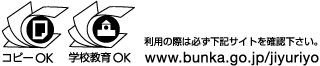  
この演習は、大学講義科目「画像工学」の講義資料として作成されています。  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この演習で使用している画像ファイル（imagefiles.zip、及び、imagefiles.zip 内の個々のファイル）については再配布を禁止します。